Commencez par charger l'ensemble de données dans un notebook et prétraitez-le

In [21]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Charger l'ensemble de données dans un notebook

df = pd.read_csv('US_Superstore_data.csv', sep=None, engine='python')

df.head()

,﻿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,"261,96",2,0,"41,9136"
1,2,CA-2016-152156,08/11/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...","731,94",3,0,"219,582"
2,3,CA-2016-138688,12/06/2016,16/06/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,"14,62",2,0,"6,8714"
3,4,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,"957,5775",5,"0,45","-383,031"
4,5,US-2015-108966,11/10/2015,18/10/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,"22,368",2,"0,2","2,5164"


In [23]:
# Apercu des colonnes et des types de données
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ﻿Row ID        9994 non-null   int64
 1   Order ID       9994 non-null   str  
 2   Order Date     9994 non-null   str  
 3   Ship Date      9994 non-null   str  
 4   Ship Mode      9994 non-null   str  
 5   Customer ID    9994 non-null   str  
 6   Customer Name  9994 non-null   str  
 7   Segment        9994 non-null   str  
 8   Country        9994 non-null   str  
 9   City           9994 non-null   str  
 10  State          9994 non-null   str  
 11  Postal Code    9994 non-null   int64
 12  Region         9994 non-null   str  
 13  Product ID     9994 non-null   str  
 14  Category       9994 non-null   str  
 15  Sub-Category   9994 non-null   str  
 16  Product Name   9994 non-null   str  
 17  Sales          9994 non-null   str  
 18  Quantity       9994 non-null   int64
 19  Discount       99

Prétraitement de données 

In [24]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne:")
print(df.isnull().sum())


Valeurs manquantes par colonne:
﻿Row ID          0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [25]:
# Voir le type de dates et si elles sont au bon format
print("Types de données avant conversion:")
print(df[['Order Date', 'Ship Date']].dtypes)

if df['Order Date'].dtype == 'object' or df['Ship Date'].dtype == 'object':
    print("Les colonnes de dates sont au format objet. Conversion nécessaire.")
else:
    print("Les colonnes de dates sont déjà au format datetime. Aucune conversion nécessaire.")

Types de données avant conversion:
Order Date    str
Ship Date     str
dtype: object
Les colonnes de dates sont déjà au format datetime. Aucune conversion nécessaire.


In [26]:
# 1. Nettoyage de la colonne 'Sales' (on retire le symbole $ et les espaces)
df['Sales'] = df['Sales'].astype(str).str.replace('$', '', regex=False)
df['Sales'] = df['Sales'].str.replace(',', '', regex=False).str.strip()
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# 2. Nettoyage de la colonne 'Profit' (on retire le symbole $ et les espaces)
df['Profit'] = df['Profit'].astype(str).str.replace('$', '', regex=False)
df['Profit'] = df['Profit'].str.replace(',', '', regex=False).str.strip()
df['Profit'] = pd.to_numeric(df['Profit'], errors='coerce')

# 3. Suppression des lignes qui n'ont pas pu être converties (valeurs vides)
df = df.dropna(subset=['Sales', 'Profit'])

Analyse par visualisation

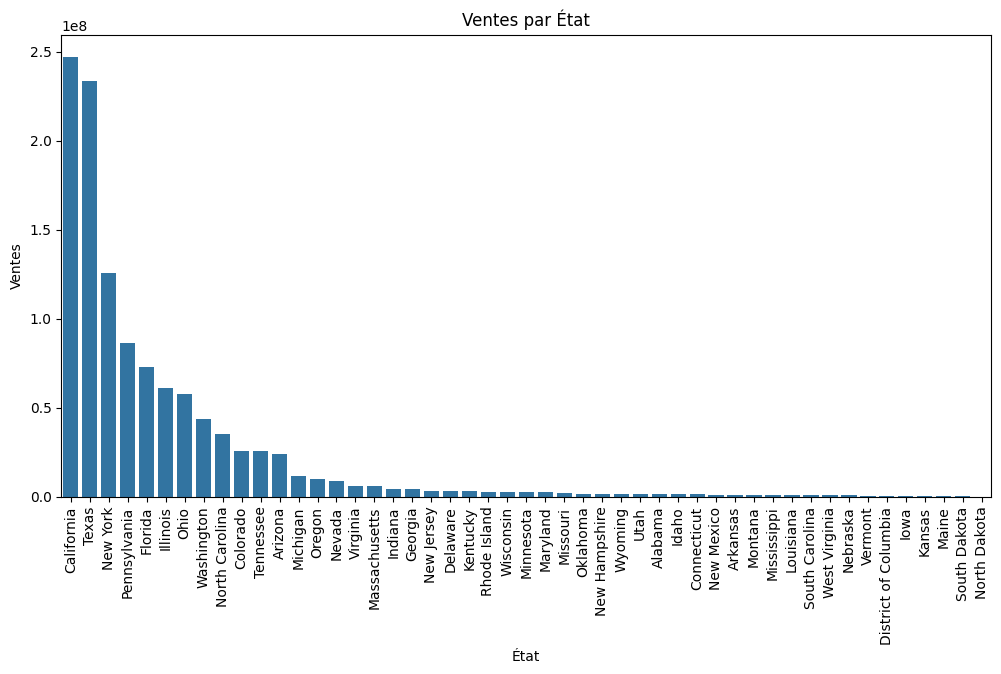

In [27]:
# Quels sont les États qui enregistrent le plus de ventes par visualisation ?

# Agréger les ventes par État
sales_by_state = df.groupby('State')['Sales'].sum().reset_index()
# Trier les États par ventes
sales_by_state = sales_by_state.sort_values(by='Sales', ascending=False)
# Visualiser les ventes par État
plt.figure(figsize=(12, 6))
sns.barplot(x='State', y='Sales', data=sales_by_state)
plt.xticks(rotation=90)
plt.title('Ventes par État')
plt.xlabel('État')
plt.ylabel('Ventes')

plt.show()


        State      Sales     Profit
0  California  247182298  456584921
1    New York  125787176  474152868


<Axes: xlabel='State', ylabel='Sales'>

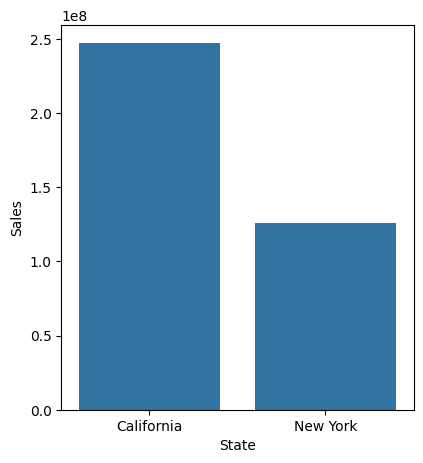

In [28]:
# Quelle est la différence entre New York et la Californie en termes de chiffre d'affaires et de bénéfices ? 
# (Comparez le chiffre d'affaires total et les bénéfices de New York et de la Californie.)

# Filtrer les données pour New York et la Californie
ny_ca_data = df[df['State'].isin(['New York', 'California'])]
# Agréger les ventes et les bénéfices par État
ny_ca_summary = ny_ca_data.groupby('State')[['Sales', 'Profit']].sum().reset_index()
print(ny_ca_summary)
# Visualiser la comparaison des ventes et des bénéfices entre New York et la Californie
plt.figure(figsize=(10, 5))
# Barplot pour les ventes
plt.subplot(1, 2, 1)
sns.barplot(x='State', y='Sales', data=ny_ca_summary)

In [29]:
# Qui est un client exceptionnel à New York ?
my_customers = df[df['State'] == 'New York']

top_ny_customer = my_customers.groupby('Customer Name')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False)
print("Top clients à New York :\n", top_ny_customer.head(5))

Top clients à New York :
                     Sales    Profit
Customer Name                      
Tom Ashbrook     11230606  39902250
Peter Fuller      4678096   3429860
Pete Kriz         4385545  14918228
Adam Bellavance   4366263  14534346
Luke Weiss        4139771   3187228


C:\Users\USER\AppData\Local\Temp\ipykernel_9932\2319412482.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_perf.index, y=state_perf['Profitability_Rate'], palette='coolwarm')


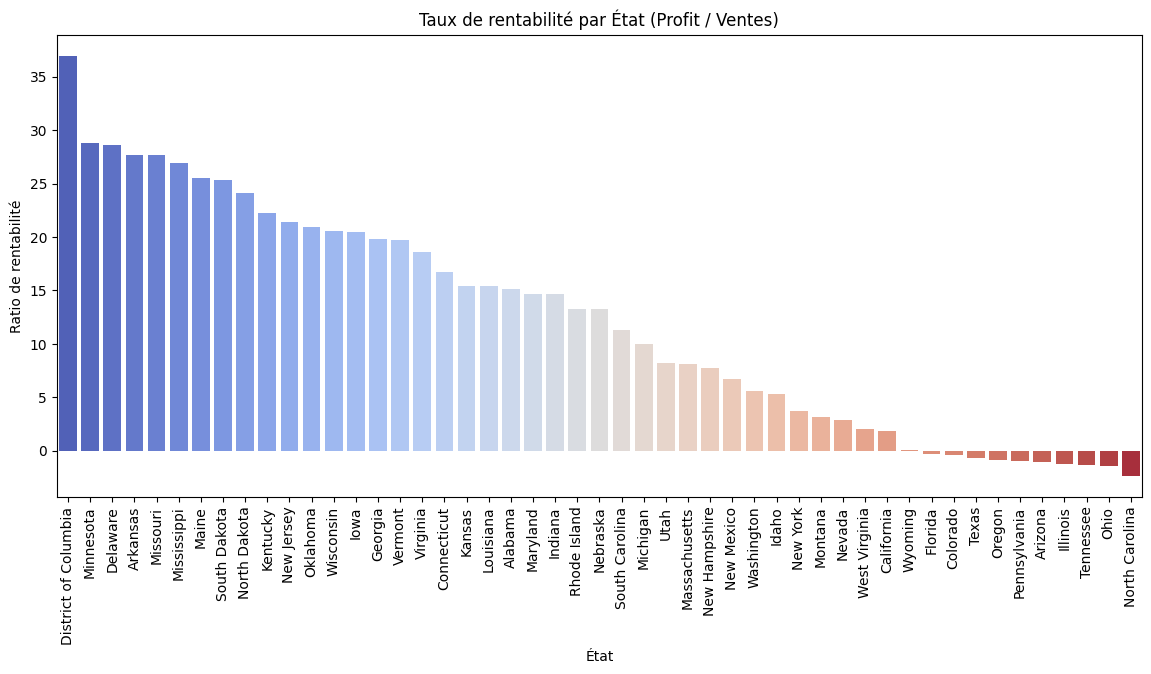

In [30]:
# Existe-t-il des différences de rentabilité entre les États ?

state_perf = df.groupby('State')[['Sales', 'Profit']].sum()
state_perf['Profitability_Rate'] = state_perf['Profit']/state_perf['Sales']
state_perf = state_perf.sort_values(by='Profitability_Rate', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=state_perf.index, y=state_perf['Profitability_Rate'], palette='coolwarm')
plt.xticks(rotation=90)
plt.title('Taux de rentabilité par État (Profit / Ventes)')
plt.xlabel('État')
plt.ylabel('Ratio de rentabilité')
plt.show()


Le principe de Pareto, également connu sous le nom de loi des 80/20, est un concept issu des travaux de l'économiste italien Vilfredo Pareto. Il stipule qu'environ 80 % des effets proviennent de 20 % des causes. Par exemple, identifier les 20 % de produits qui génèrent 80 % des ventes ou les 20 % de clients qui contribuent à 80 % des bénéfices peut aider à prioriser les efforts et les ressources. Cette approche peut améliorer l'efficacité et la performance des stratégies commerciales.

In [32]:
# Peut-on appliquer le principe de Pareto aux clients et aux bénéfices ? (Déterminez si 20 % des clients contribuent à 80 % des bénéfices.)

# Groupement par client et tri décroissant par Profit
cust_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).to_frame()

# Calcul du pourcentage cumulé des bénéfices
cust_profit['Cum_Profit_Pct'] = cust_profit['Profit'].cumsum() / cust_profit['Profit'].sum()

# Calcul du pourcentage cumulé des clients
cust_profit['Cum_Cust_Pct'] = np.arange(1, len(cust_profit) + 1) / len(cust_profit)

# Vérification du point 20%
pct_20_clients = cust_profit[cust_profit['Cum_Cust_Pct'] <= 0.20].iloc[-1]
print(f"Les premiers 20% des clients génèrent {pct_20_clients['Cum_Profit_Pct']*100:.2f}% des bénéfices.")


Les premiers 20% des clients génèrent 87.21% des bénéfices.


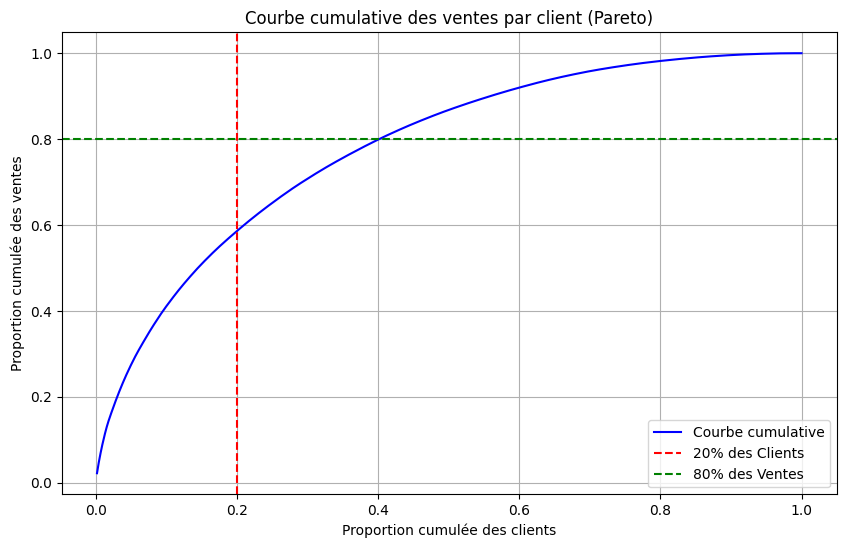

Les premiers 20% des clients génèrent 58.55% des ventes.


In [33]:
# Groupement par client et tri décroissant par Sales
cust_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).to_frame()
cust_sales['Cum_Sales_Pct'] = cust_sales['Sales'].cumsum() / cust_sales['Sales'].sum()
cust_sales['Cum_Cust_Pct'] = np.arange(1, len(cust_sales) + 1) / len(cust_sales)

# Graphique de la courbe de Pareto (Courbe ABC / Cumulative)
plt.figure(figsize=(10, 6))
plt.plot(cust_sales['Cum_Cust_Pct'].values, cust_sales['Cum_Sales_Pct'].values, label='Courbe cumulative', color='blue')
plt.axvline(x=0.20, color='red', linestyle='--', label='20% des Clients')
plt.axhline(y=0.80, color='green', linestyle='--', label='80% des Ventes')
plt.title('Courbe cumulative des ventes par client (Pareto)')
plt.xlabel('Proportion cumulée des clients')
plt.ylabel('Proportion cumulée des ventes')
plt.legend()
plt.grid(True)
plt.show()

# Conclusion textuelle automatique
pct_20_sales = cust_sales[cust_sales['Cum_Cust_Pct'] <= 0.20].iloc[-1]
print(f"Les premiers 20% des clients génèrent {pct_20_sales['Cum_Sales_Pct']*100:.2f}% des ventes.")


C:\Users\USER\AppData\Local\Temp\ipykernel_9932\3639510666.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=top20_city_sales.values, y=top20_city_sales.index, palette='Blues_r')
C:\Users\USER\AppData\Local\Temp\ipykernel_9932\3639510666.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=top20_city_profit.values, y=top20_city_profit.index, palette='Greens_r')


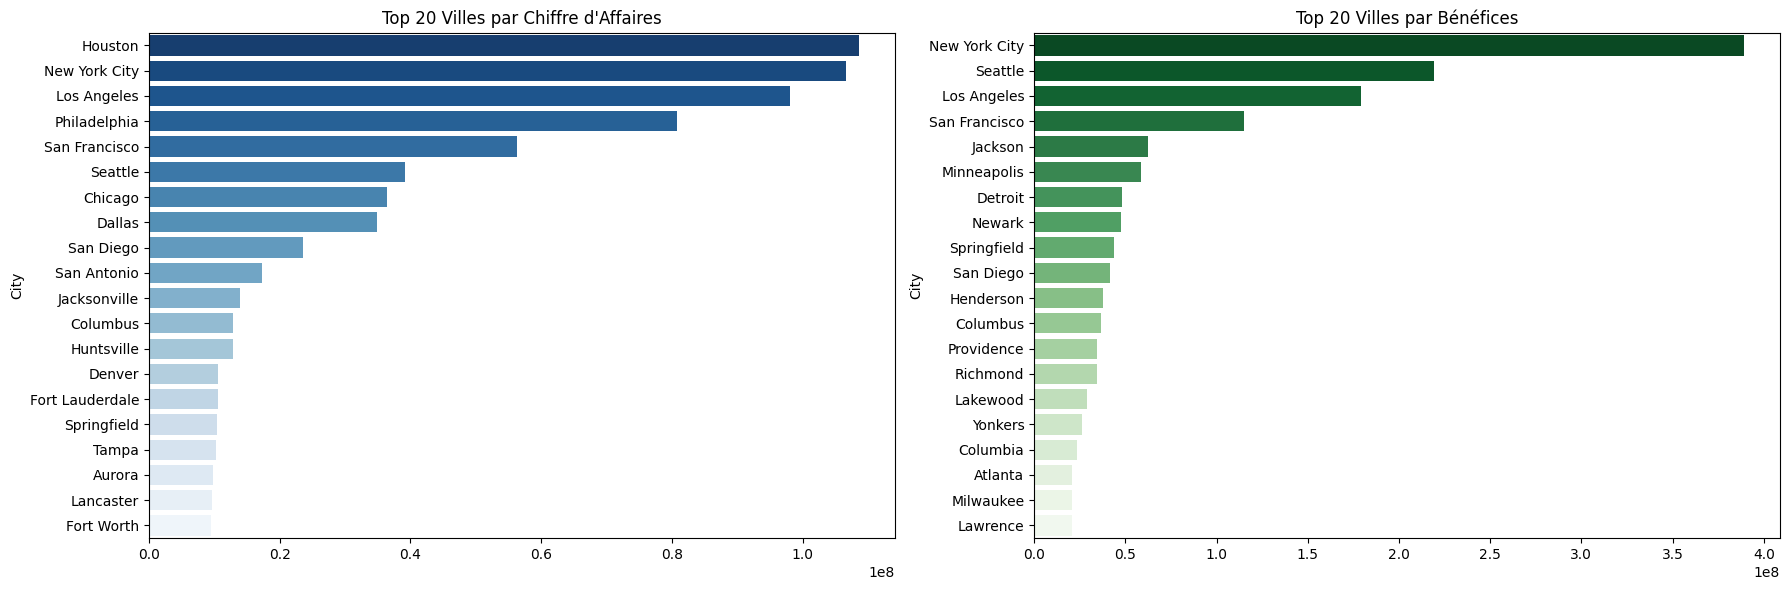

                     Sales     Profit  Profitability
City                                                
Minneapolis        1646446   58279813      35.397343
Providence         1239271   34573838      27.898529
Richmond           1382576   34270459      24.787396
Milwaukee           904916   20600081      22.764633
Henderson          1707484   37693667      22.075561
Lawrence           1193542   20572600      17.236595
Yonkers            1609333   26331355      16.361657
Jackson            4636206   62436861      13.467232
Atlanta            1694314   20774543      12.261330
Lakewood           3648776   28822880       7.899328
Detroit            6594994   48016046       7.280681
Newark             7860468   47684473       6.066366
Seattle           39106626  219116376       5.603050
Columbia           4546613   23495999       5.167803
Springfield       10469788   43863451       4.189526
New York City    106643036  389435030       3.651762
Columbus          12947163   36567232       2.

In [34]:
# Quelles sont les 20 premières villes en termes de chiffre d'affaires ? 
# Et les 20 premières villes en termes de bénéfice ? 
# Existe-t-il des différences de rentabilité entre les villes ? (Identifiez les 20 premières villes en fonction du chiffre d'affaires total et du bénéfice total, puis analysez les différences de rentabilité entre ces villes.)

# Top 20 Villes par Ventes
top20_city_sales = df.groupby('City')['Sales'].sum().sort_values(ascending=False).head(20)

# Top 20 Villes par Bénéfices
top20_city_profit = df.groupby('City')['Profit'].sum().sort_values(ascending=False).head(20)

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(ax=axes[0], x=top20_city_sales.values, y=top20_city_sales.index, palette='Blues_r')
axes[0].set_title('Top 20 Villes par Chiffre d\'Affaires')

sns.barplot(ax=axes[1], x=top20_city_profit.values, y=top20_city_profit.index, palette='Greens_r')
axes[1].set_title('Top 20 Villes par Bénéfices')

plt.tight_layout()
plt.show()

# Analyse des différences de rentabilité entre ces villes principales
city_perf = df.groupby('City')[['Sales', 'Profit']].sum()
city_perf['Profitability'] = city_perf['Profit'] / city_perf['Sales']
# Filtrer sur l'union des deux tops 20 pour analyser la rentabilité des grandes villes
top_cities = list(set(top20_city_sales.index).union(set(top20_city_profit.index)))
print(city_perf.loc[top_cities].sort_values(by='Profitability', ascending=False))


C:\Users\USER\AppData\Local\Temp\ipykernel_9932\2234458457.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20_customers_sales.values, y=top20_customers_sales.index, palette='magma')


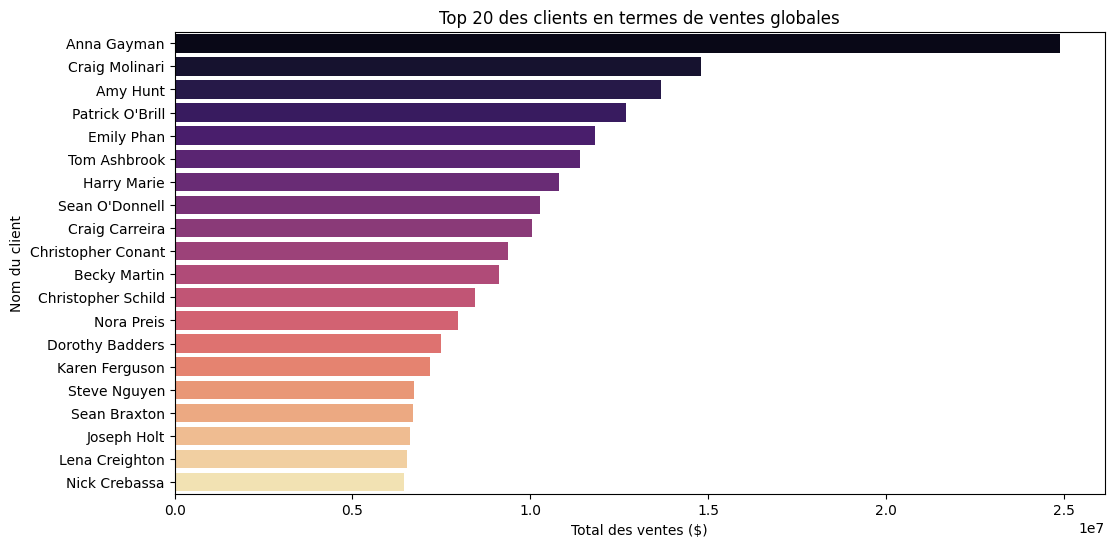

In [35]:
# Quels sont les 20 meilleurs clients en termes de ventes ?
top20_customers_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top20_customers_sales.values, y=top20_customers_sales.index, palette='magma')
plt.title('Top 20 des clients en termes de ventes globales')
plt.xlabel('Total des ventes ($)')
plt.ylabel('Nom du client')
plt.show()


In [ ]:
# Tracez la courbe cumulative des ventes par client. Peut-on appliquer le principe de Pareto aux clients et aux ventes ?
